In [1]:
import numpy as np
from pillow_lab_rotation.ctds import CTDS
from pillow_lab_rotation.simulate import CTDSSim
from pillow_lab_rotation.plotting import plot_ctds_matrices
import matplotlib.pyplot as plt

plt.style.use('../Js.mplstyle')

# Making fake data to recover with model

In [2]:
Ne, Ni = 8, 8
N = Ne + Ni
De, Di = 2, 2
D = De + Di

In [3]:
simulation = CTDSSim(De, Di, Ne, Ni)
np.random.seed(42)
simulation.create_params()

In [4]:
A, C, Q, Q0, mu0, R = simulation.get_params()

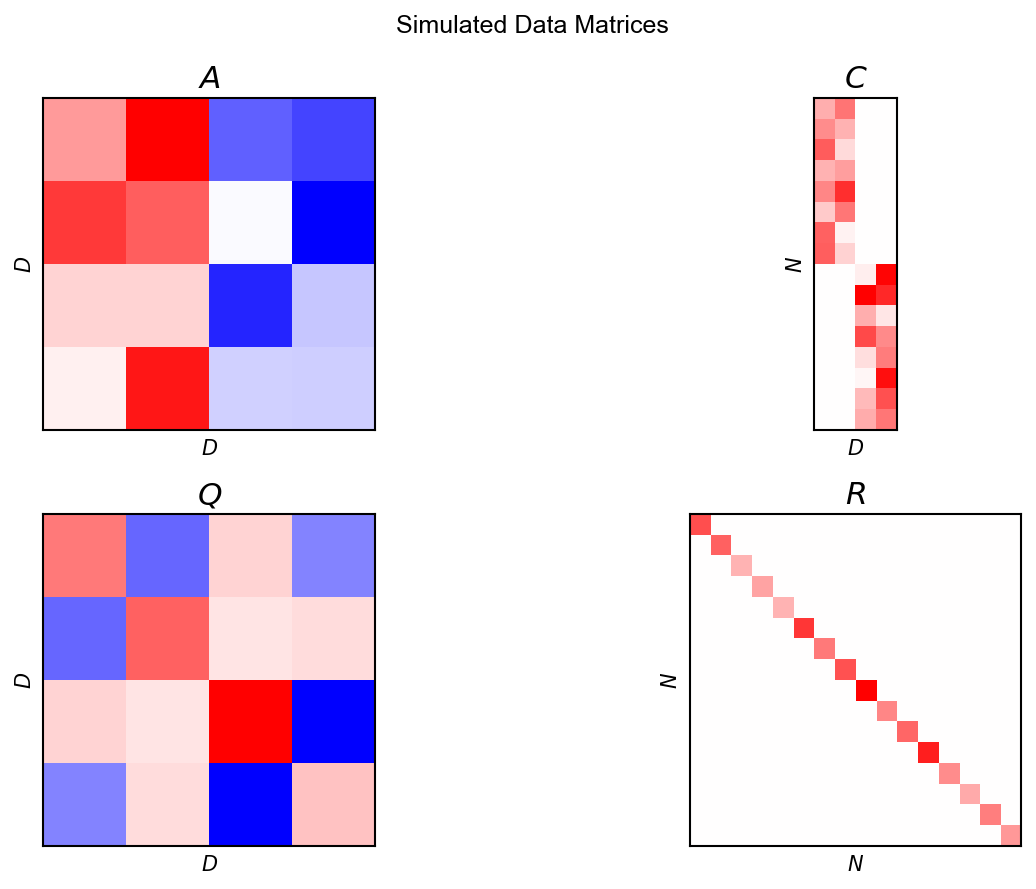

In [5]:
plot_ctds_matrices(A, C, Q, R)

In [6]:
X, Y = simulation.simulate(1000, 50)

# Try fitting

In [7]:
ctds = CTDS(De, Di, Ne, Ni)

In [8]:
ctds.fit(Y, True)

Iteration 1
LL: -33.57655
Iteration 2
LL: -27.23835
Iteration 3
LL: -26.63103
Iteration 4
LL: -26.36438
Iteration 5
LL: -26.20181
Iteration 6
LL: -25.89654
Iteration 7
LL: -25.60908
Iteration 8
LL: -25.48550
Iteration 9
LL: -25.43668
Iteration 10
LL: -25.41375
Iteration 11
LL: -25.40101
Iteration 12
LL: -25.39317
Iteration 13
LL: -25.38798
Iteration 14
LL: -25.38434
Iteration 15
LL: -25.38168
Iteration 16
LL: -25.37965
Iteration 17
LL: -25.37806
Iteration 18
LL: -25.37679
Iteration 19
LL: -25.37575
Iteration 20
LL: -25.37489
Iteration 21
LL: -25.37417
Iteration 22
LL: -25.37355
Iteration 23
LL: -25.37301
Iteration 24
LL: -25.37254
Iteration 25
LL: -25.37214
Iteration 26
LL: -25.37177
Iteration 27
LL: -25.37145
Iteration 28
LL: -25.37116
Iteration 29
LL: -25.37089
Iteration 30
LL: -25.37066
Iteration 31
LL: -25.37044
Iteration 32
LL: -25.37024
Iteration 33
LL: -25.37005
Iteration 34
LL: -25.36988
Iteration 35
LL: -25.36973
Iteration 36
LL: -25.36958
Iteration 37
LL: -25.36945
Iteration 

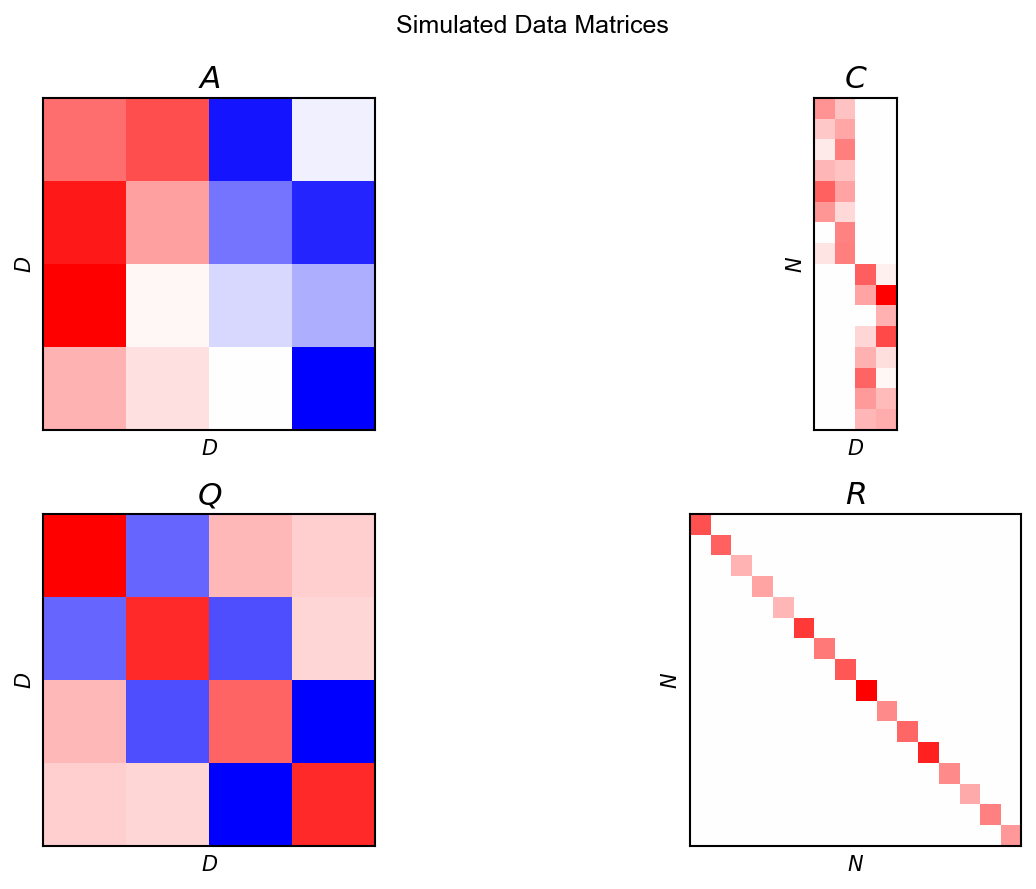

In [9]:
plot_ctds_matrices(ctds.A, ctds.C, ctds.Q, ctds.R)

In [10]:
x_pred, pred_covs, obs_mean, obs_cov, x_filt, post_covs, LL = ctds.predict(Y)

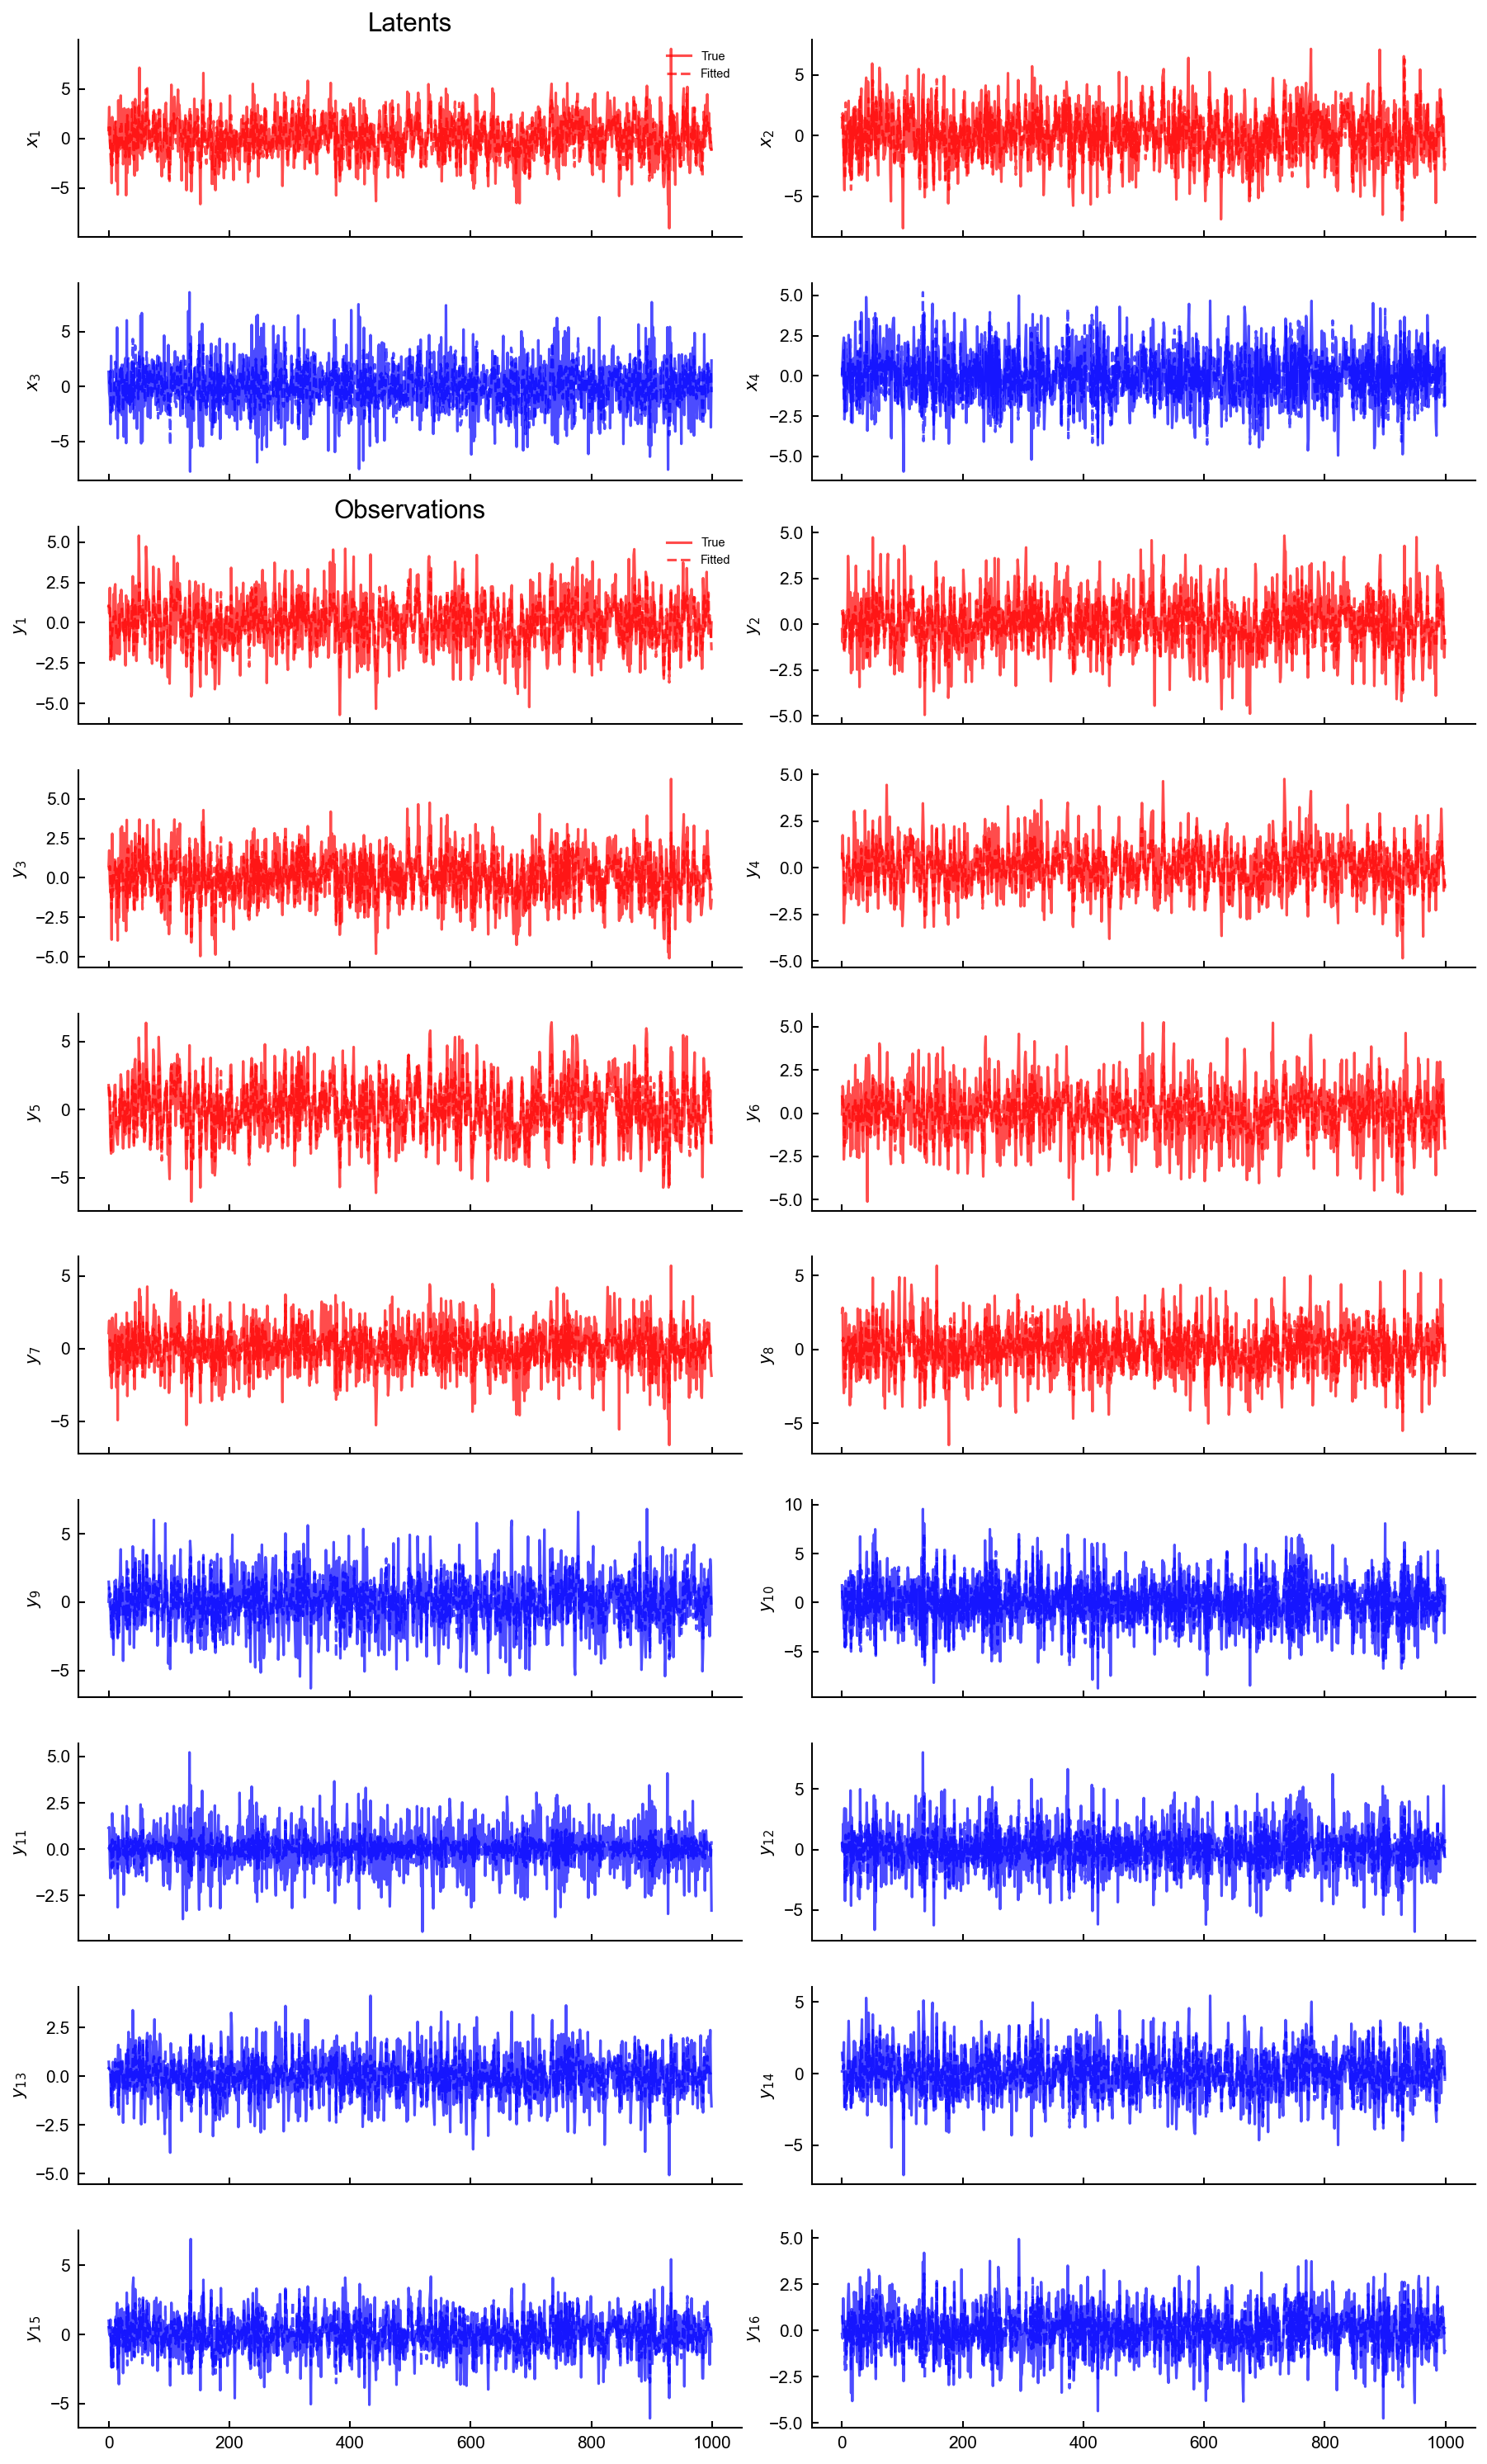

In [11]:
from pillow_lab_rotation.plotting import plot_trajectories
plot_trajectories(X, x_filt, Y, obs_mean, De, Ne)

### MSE between fit parameters and ground-truth parameters should go down monotonically with the amount of data

In [27]:
Ne, Ni = 8, 8
N = Ne + Ni
De, Di = 2, 2
D = De + Di

simulation = CTDSSim(De, Di, Ne, Ni)
np.random.seed(42)
simulation.create_params()

trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
time_points = 100
X_all, Y_all = simulation.simulate(time_points, trial_list[-1])

A_loss = []
C_loss = []
Q_loss = []
R_loss = []
A_true, C_true, Q_true, Q0_true, _, R_true = simulation.get_params()

for n_trials in trial_list:
    print(f'Fitting with {n_trials} trials')
    Y = Y_all[:n_trials]
    np.random.seed(0)
    ctds = CTDS(De, Di, Ne, Ni)
    ctds.fit(Y, max_iters=50)

    C_prime = ctds.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ ctds.A @ H
    C_rec = ctds.C @ H
    Q_rec = H_inv @ ctds.Q @ H_inv.T

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((ctds.R - R_true)**2))

Fitting with 50 trials
Fitting with 100 trials
Fitting with 200 trials
Fitting with 500 trials
Fitting with 1000 trials
Fitting with 1500 trials
Fitting with 2000 trials
Fitting with 5000 trials
Fitting with 10000 trials
Fitting with 20000 trials
Fitting with 40000 trials


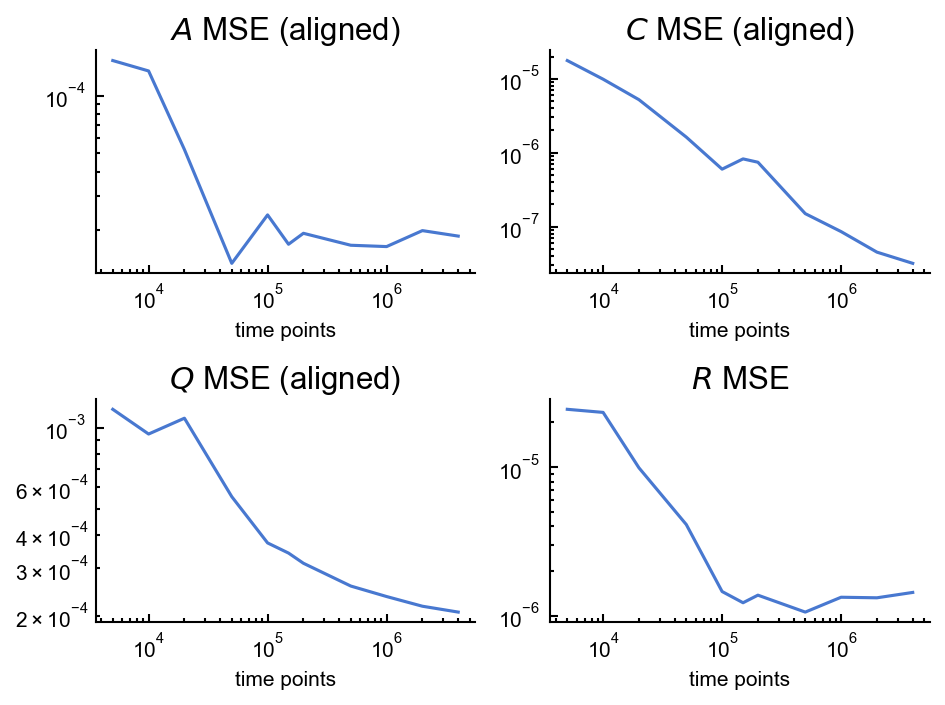

In [26]:
fig, axes = plt.subplots(2, 2)
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)', '$R$ MSE']
losses = [A_loss, C_loss, Q_loss, R_loss]

for ax, title, loss in zip(axes.flat, titles, losses):
    ax.plot(time_points * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.tight_layout()